In [1]:
import os
import pertpy as pt
import scanpy as sc
import pandas as pd
import mudata as mu
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

milo = pt.tl.Milo()

from pertpy.tools import Milo


/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata_age_cd4= sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_scvi.h5ad")

In [3]:
adata_age_cd4

AnnData object with n_obs × n_vars = 596486 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age (years)', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age i

In [4]:
adata_age_cd4.obs['pica_cell_type_complete_01_gdT_corrected'].unique()
adata_age_cd4.obs['pica_cell_type_complete_01_gdT_corrected'].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD4 naive/Tcm    407516
CD4 Tem           96510
Tfh               45002
Treg              39431
CD4 cytoT          8027
Name: count, dtype: int64

In [5]:
adata_age_cd4.obs["pica_id"].unique()
adata_age_cd4.obs["pica_id"].value_counts()

pica_id
PICA0008    8046
PICA0010    7871
PICA0024    7829
PICA0119    7760
PICA0089    7608
            ... 
PICA0006    1576
PICA0004    1203
PICA0003    1169
PICA0002    1009
PICA0005     685
Name: count, Length: 128, dtype: int64

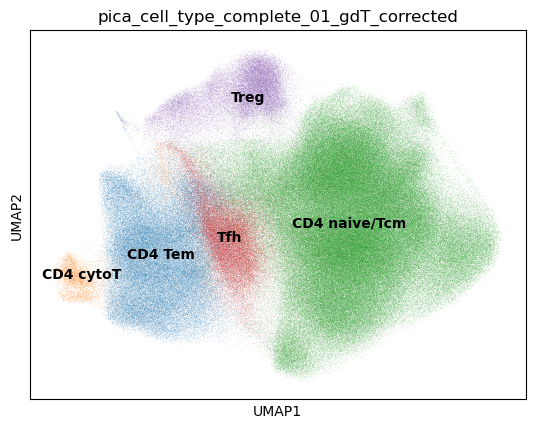

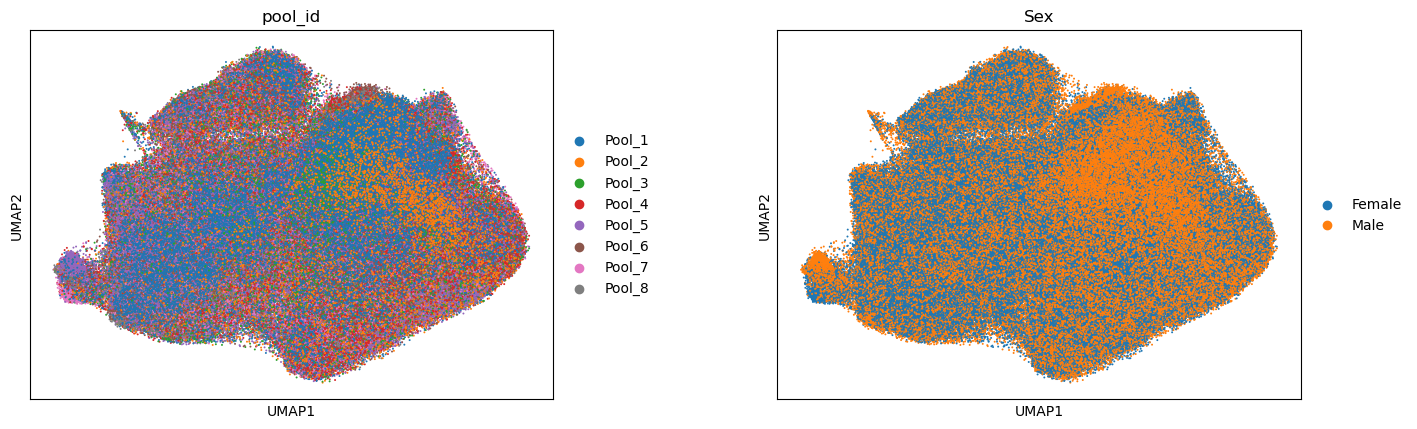

In [6]:
sc.pl.umap(adata_age_cd4, color=["pica_cell_type_complete_01_gdT_corrected"], legend_loc="on data")
sc.pl.umap(adata_age_cd4, color=["pool_id", "Sex"], wspace=0.3, size=8)

### Prepare for Milo analysis

In [ ]:
adata_age_cd4.obs['Batch'] = adata_age_cd4.obs['sequencing_batch'].map(
        {
            '20240530_WGS_20240530_sc_PICA0001-PICA0007': "Batch01",
            '20240918_WGS_20240924_sc_PICA0008-PICA0032': "Batch02",
            '20241106_WGS_20241106_sc_PICA0033-PICA0069': "Batch03",
            '20250114_WGS_20241218_sc_PICA0071-PICA0097': "Batch04",
            '20250324_WGS_20250324_sc_PICA0098-PICA0118': "Batch05",
            '20250612_WGS_20250612_sc_PICA0119-PICA0146': "Batch06",
            '20250814_WGS_20250814_sc_PICA0147-PICA0173': "Batch07"
        }
    )

adata_age_cd4.obs["Age_group"] = pd.Categorical(
        adata_age_cd4.obs["Age_group"],
        categories=["0–3", "4–6", "7–10", "11–14", "15–18"],
        ordered=True,
    )
"""
#centre age (compute difference between sex at different age)
adata_age_cd4.obs["Age_years"] = (
    adata_age_cd4.obs["Age (years)"]
    - adata_age_cd4.obs["Age (years)"].mean()
)
"""
adata_age_cd4.obs = adata_age_cd4.obs.rename(columns={
    "Age (years)": "Age_years"
})

adata_age_cd4.obs["Batch"] = adata_age_cd4.obs["Batch"].astype("category")
adata_age_cd4.obs["Age_years"] = adata_age_cd4.obs["Age_years"].astype("float")
adata_age_cd4.obs["Sex"] = adata_age_cd4.obs["Sex"].astype("category")
adata_age_cd4.obs["Age"] = adata_age_cd4.obs["Age"].astype("int")

In [8]:
adata_age_cd4.obs["Sex"].value_counts()


Sex
Male      321837
Female    274649
Name: count, dtype: int64

In [9]:
adata_age_cd4.obs["Age_years"].value_counts().sort_index()


Age_years
0.05     6493
0.07     7871
0.14     1576
0.35     6804
0.48     6077
         ... 
16.16    5594
16.20    5700
16.29    3669
16.78    4525
17.03    7608
Name: count, Length: 122, dtype: int64

In [10]:
adata_age_cd4.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      151860
4–6      134748
7–10      91711
11–14    162356
15–18     55811
Name: count, dtype: int64

In [ ]:
adata_age_cd4.obs["Age"].value_counts().sort_index()

In [ ]:
adata_age_cd4.obs.drop_duplicates(subset="pica_id").groupby(["Age_years", "Sex"]).size().reset_index(name="n_donors")

,Age_years,Sex,n_donors
0,0.05,Female,0
1,0.05,Male,1
2,0.07,Female,1
3,0.07,Male,0
4,0.14,Female,0
...,...,...,...
239,16.29,Male,1
240,16.78,Female,0
241,16.78,Male,1
242,17.03,Female,1


In [ ]:
adata_age_cd4.obs.drop_duplicates(subset="pica_id").groupby(["Age", "Sex"]).size().reset_index(name="n_donors")

,Age,Sex,n_donors
0,0,Female,3
1,0,Male,7
2,1,Female,1
3,1,Male,4
4,2,Female,1
5,2,Male,7
6,3,Female,6
7,3,Male,2
8,4,Female,6
9,4,Male,6


In [11]:
milo = pt.tl.Milo()
mdata_cd4 = milo.load(adata_age_cd4)

In [12]:
mdata_cd4

MuData object with n_obs × n_vars = 596486 × 38606
  2 modalities
    rna:	596486 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Batch'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'neighbors', 'sequencing_batch_colors', 'umap', 'pica_cell_type_complete_01_gdT_corrected_colors', 'pool_id_colors', 'Sex_colors'
      obsm:	'X_scVI', 'X_umap'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	0 x 0

In [13]:
# Build KNN graph
sc.pp.neighbors(mdata_cd4["rna"], use_rep="X_scVI", n_neighbors=150)

In [14]:
# Build neighbourhood graph
milo.make_nhoods(mdata_cd4["rna"], prop=0.1)

In [15]:
mdata_cd4["rna"].obsm["nhoods"]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 15790561 stored elements and shape (596486, 32149)>

In [16]:
mdata_cd4["rna"][mdata_cd4["rna"].obs["nhood_ixs_refined"] != 0].obs[["nhood_ixs_refined", "nhood_kth_distance"]]

,nhood_ixs_refined,nhood_kth_distance
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCATTCGTAGTGC,1,3.950188
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAAGTGCAGCACGTCG,1,3.128820
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAAGTTACACAACATC,1,3.299845
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AACAGACAGAGCGACA,1,3.286461
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AACAGCCTCCACAGGT,1,3.817779
...,...,...
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTCATCGCAACGTACT,1,3.643885
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTGACTATCCAATTAA,1,3.361250
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTGTCGCCACCGGAAG,1,3.248476
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTTCATGAGCAATTGT,1,3.210419


Text(0, 0.5, '# nhoods')

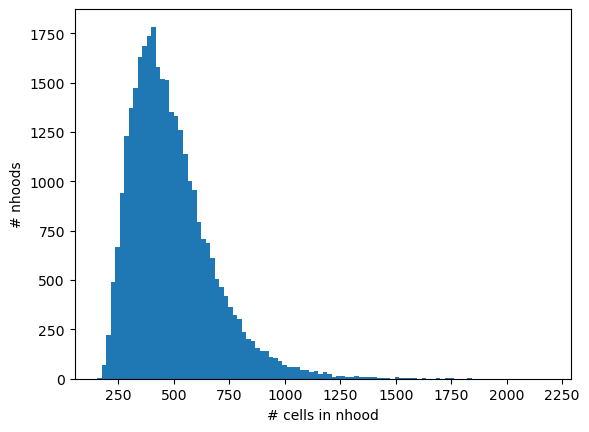

In [17]:
nhood_size = np.array(mdata_cd4["rna"].obsm["nhoods"].sum(0)).ravel()
plt.hist(nhood_size, bins=100)
plt.xlabel("# cells in nhood")
plt.ylabel("# nhoods")

In [18]:
# count cells in neighbourhood
mdata_cd4= milo.count_nhoods(mdata_cd4, sample_col="pica_id") 

In [19]:
mdata_cd4

MuData object with n_obs × n_vars = 596486 × 38606
  2 modalities
    rna:	596486 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Batch', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'neighbors', 'sequencing_batch_colors', 'umap', 'pica_cell_type_complete_01_gdT_corrected_colors', 'pool_id_colors', 'Sex_colors', 'nhood_neighbors_key'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 32149
      var:	'index_cell', 'kth_distance'

In [20]:
mdata_cd4["milo"]

AnnData object with n_obs × n_vars = 128 × 32149
    var: 'index_cell', 'kth_distance'
    uns: 'sample_col'

In [ ]:
donor_meta = (
    adata_age_cd4.obs[["pica_id", "Age_years","Age", "Sex", "Batch"]]
    .drop_duplicates("pica_id")
    .set_index("pica_id")
)
donor_meta = donor_meta.loc[mdata_cd4["milo"].obs_names]

In [ ]:
mdata_cd4["milo"].obs["Age_years"] = donor_meta["Age_years"].values
mdata_cd4["milo"].obs["Sex"] = donor_meta["Sex"].values
mdata_cd4["milo"].obs["Batch"] = donor_meta["Batch"].values
mdata_cd4["milo"].obs["Age"] = donor_meta["Age"].values

In [ ]:
"""
mdata_cd4["milo"].obs["Age_group"] = pd.Categorical(
    mdata_cd4["milo"].obs["Age_group"],
    categories=["0–3", "4–6", "7–10", "11–14", "15–18"],
    ordered=True
)
"""
mdata_cd4["milo"].obs["Sex"] = mdata_cd4["milo"].obs["Sex"].astype("category")
mdata_cd4["milo"].obs["Age_years"] = mdata_cd4["milo"].obs["Age_years"].astype("float")
mdata_cd4["milo"].obs["Batch"] = mdata_cd4["milo"].obs["Batch"].astype("category")
mdata_cd4["milo"].obs["Age"] = mdata_cd4["milo"].obs["Age"].astype("int")



In [24]:
mdata_cd4["milo"].obs["Age_years"].value_counts()

Age_years
14.97    3
9.70     2
1.17     2
6.19     2
6.66     2
        ..
2.15     1
0.62     1
16.20    1
2.72     1
15.31    1
Name: count, Length: 122, dtype: int64

In [25]:
mdata_cd4["milo"].obs["Sex"].value_counts()

Sex
Male      75
Female    53
Name: count, dtype: int64

In [ ]:
mdata_cd4["milo"].obs["Age"].value_counts()

In [26]:
mdata_cd4

MuData object with n_obs × n_vars = 596486 × 38606
  2 modalities
    rna:	596486 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Batch', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'neighbors', 'sequencing_batch_colors', 'umap', 'pica_cell_type_complete_01_gdT_corrected_colors', 'pool_id_colors', 'Sex_colors', 'nhood_neighbors_key'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 32149
      obs:	'Age_years', 'Sex', 'Batch'


### DA testing with GLM

In [27]:
mdata_cd4

MuData object with n_obs × n_vars = 596486 × 38606
  2 modalities
    rna:	596486 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Batch', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'neighbors', 'sequencing_batch_colors', 'umap', 'pica_cell_type_complete_01_gdT_corrected_colors', 'pool_id_colors', 'Sex_colors', 'nhood_neighbors_key'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 32149
      obs:	'Age_years', 'Sex', 'Batch'


In [ ]:
milo.da_nhoods(
    mdata_cd4,
    design="~ Age_years * Sex + Batch",   # Age_group last = main effect of interest
    solver="pydeseq2"                  # use "edger" only if you set up rpy2+edgeR
)

In [ ]:
"""
milo.da_nhoods(
    mdata_cd4,
    design="~ Age * Sex + Batch",   # Age_group last = main effect of interest
    solver="pydeseq2"                  # use "edger" only if you set up rpy2+edgeR
)
"""

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/pydeseq2/dds.py:539: UserWarning: Every gene contains at least one zero, cannot compute log geometric means. Switching to iterative mode.
  self.fit_size_factors(
Fitting dispersions...
... done in 6.50 seconds.

Fitting MAP dispersions...
... done in 6.58 seconds.



Fitting dispersions...
... done in 6.53 seconds.

Fitting MAP dispersions...
... done in 6.67 seconds.

Fitting dispersions...
... done in 6.49 seconds.

Fitting MAP dispersions...
... done in 6.29 seconds.

Fitting dispersions...
... done in 6.25 seconds.

Fitting MAP dispersions...
... done in 6.32 seconds.

Fitting dispersions...
... done in 6.64 seconds.

Fitting MAP dispersions...
... done in 6.32 seconds.

Fitting dispersions...
... done in 6.27 seconds.

Fitting MAP dispersions...
... done in 6.23 seconds.

Fitting dispersions...
... done in 6.19 seconds.

Fitting MAP dispersions...
... done in 6.29 seconds.

Fitting dispersions...
... done in 6.15 seconds.

Fitting MAP dispersions...
... done in 6.23 seconds.

Fitting dispersions...
... done in 6.38 seconds.

Fitting MAP dispersions...
... done in 6.20 seconds.

Fitting dispersions...
... done in 6.48 seconds.

Fitting MAP dispersions...
... done in 6.31 seconds.

Iterative size factor fitting did not converge.
... done in 5506

Log2 fold change & Wald test p-value: Batch Batch07 vs Batch01
       baseMean  log2FoldChange     lfcSE      stat        pvalue      padj
0      4.096742        0.361029  0.732373  0.492958  6.220423e-01  0.848706
1      4.456990       -0.541588  1.022191 -0.529830  5.962297e-01  0.835701
2      3.854566        0.720503  1.181372  0.609887  5.419368e-01  0.808732
3      3.749897       -1.738746  0.730097 -2.381526  1.724107e-02  0.136646
4      3.899418       -1.827768  0.745507 -2.451712  1.421786e-02  0.118535
...         ...             ...       ...       ...           ...       ...
32144  2.157312       -2.544195  0.847715 -3.001238  2.688843e-03  0.033518
32145  4.801572       -3.712860  0.892757 -4.158868  3.198280e-05  0.001056
32146  4.902330       -4.538224  0.909894 -4.987638  6.112198e-07  0.000045
32147  2.667069       -1.126408  0.914272 -1.232028  2.179386e-01  0.573721
32148  3.522143       -3.479444  0.808543 -4.303352  1.682330e-05  0.000628

[32149 rows x 6 columns]

... done in 2.82 seconds.



In [29]:
mdata_cd4["milo"].obs

,Batch,Age_years,Sex,pica_id
PICA0001,Batch01,2.09,Male,PICA0001
PICA0002,Batch01,15.09,Male,PICA0002
PICA0003,Batch01,0.83,Male,PICA0003
PICA0004,Batch01,1.46,Male,PICA0004
PICA0005,Batch01,9.30,Male,PICA0005
...,...,...,...,...
PICA0164,Batch07,2.15,Male,PICA0164
PICA0166,Batch07,0.62,Male,PICA0166
PICA0168,Batch07,16.20,Male,PICA0168
PICA0169,Batch07,2.72,Male,PICA0169


In [30]:
mdata_cd4["milo"].var

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR
0,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.950188,4.096742,0.361029,6.220423e-01,0.848706,0.845871
1,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.128820,4.456990,-0.541588,5.962297e-01,0.835701,0.832896
2,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.299845,3.854566,0.720503,5.419368e-01,0.808732,0.805911
3,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.286461,3.749897,-1.738746,1.724107e-02,0.136646,0.134154
4,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.817779,3.899418,-1.827768,1.421786e-02,0.118535,0.116394
...,...,...,...,...,...,...,...
32144,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.643885,2.157312,-2.544195,2.688843e-03,0.033518,0.032763
32145,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.361250,4.801572,-3.712860,3.198280e-05,0.001056,0.001022
32146,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.248476,4.902330,-4.538224,6.112198e-07,0.000045,0.000044
32147,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.210419,2.667069,-1.126408,2.179386e-01,0.573721,0.567693


In [ ]:
# Save Milo DA table
mdata_cd4["milo"].var.to_csv("/scratch/user/s4575250/BIOX7018_thesis/Results/PICA_Batch001-Batch007/03_milo/cd4_milo_results.csv")

# Save nhood definitions (optional but useful)
import scipy.sparse as sp
sp.save_npz("/scratch/user/s4575250/BIOX7018_thesis/Results/PICA_Batch001-Batch007/03_milo/cd4_nhoods_matrix.npz", mdata_cd4["rna"].obsm["nhoods"])

# Save sample metadata used in design
mdata_cd4["milo"].obs.to_csv("/scratch/user/s4575250/BIOX7018_thesis/Results/PICA_Batch001-Batch007/03_milo/cd4_milo_sample_metadata.csv")

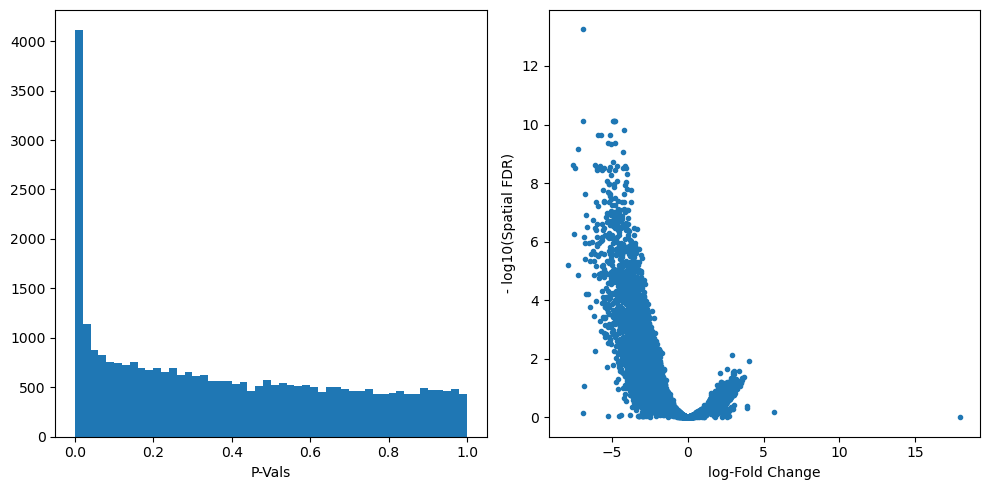

In [32]:
# QC
old_figsize = plt.rcParams["figure.figsize"]
plt.rcParams["figure.figsize"] = [10, 5]
plt.subplot(1, 2, 1)
plt.hist(mdata_cd4["milo"].var.PValue, bins=50)
plt.xlabel("P-Vals")
plt.subplot(1, 2, 2)
plt.plot(mdata_cd4["milo"].var.logFC, -np.log10(mdata_cd4["milo"].var.SpatialFDR), ".")
plt.xlabel("log-Fold Change")
plt.ylabel("- log10(Spatial FDR)")
plt.tight_layout()
plt.rcParams["figure.figsize"] = old_figsize

### Visualize embedding

In [33]:
milo.build_nhood_graph(mdata_cd4)

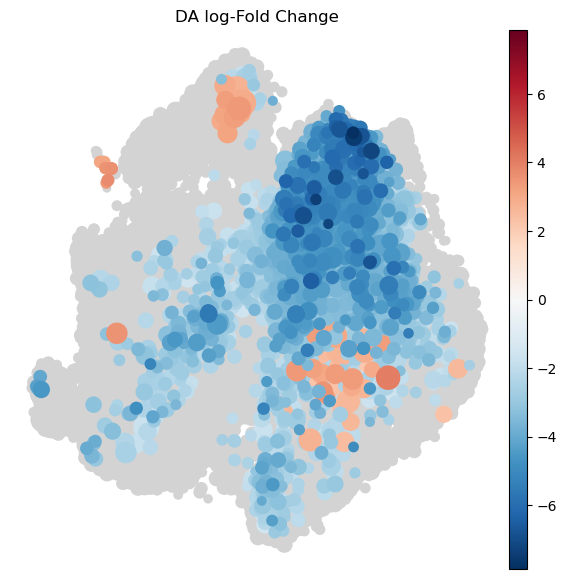

In [34]:
plt.rcParams["figure.figsize"] = [7, 7]
milo.plot_nhood_graph(
    mdata_cd4,
    alpha=0.1,  # SpatialFDR level (1%)
    min_size=1,  # Size of smallest dot
)

### Visualize by cell type

In [35]:
milo.annotate_nhoods(mdata_cd4, anno_col="pica_cell_type_complete_01_gdT_corrected")


Text(0.5, 0, 'celltype fraction')

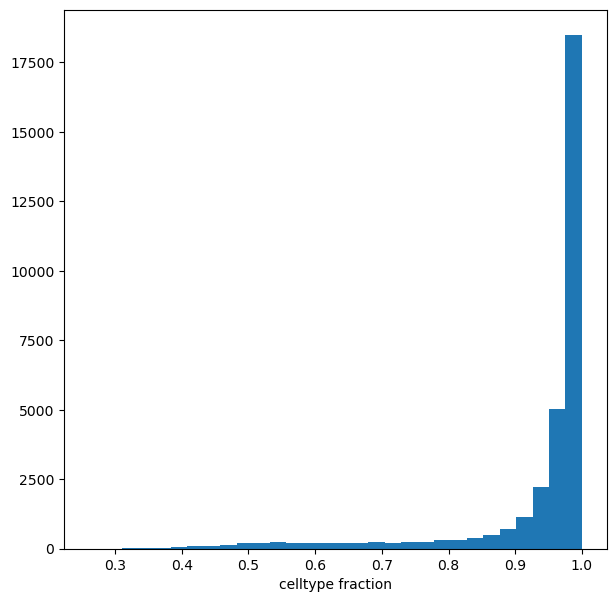

In [36]:
plt.hist(mdata_cd4["milo"].var["nhood_annotation_frac"], bins=30)
plt.xlabel("celltype fraction")

In [37]:
mdata_cd4["milo"].var["nhood_annotation"] = mdata_cd4["milo"].var["nhood_annotation"].cat.add_categories("Mixed")
mdata_cd4["milo"].var.loc[mdata_cd4["milo"].var["nhood_annotation_frac"] < 0.6, "nhood_annotation"] = "Mixed"

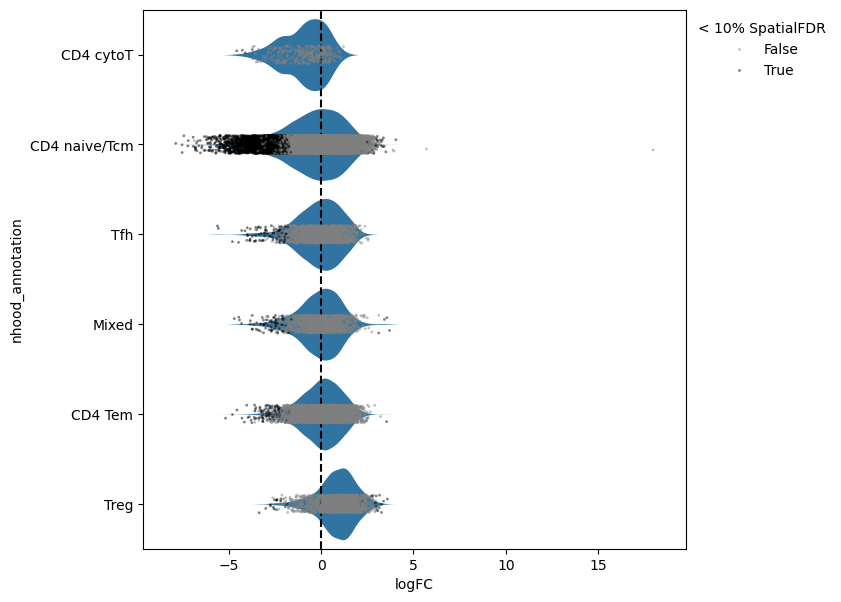

In [38]:
milo.plot_da_beeswarm(mdata_cd4, alpha=0.1)

KeyError: 'Could not find key nhood_annotation in .var_names or .obs.columns.'

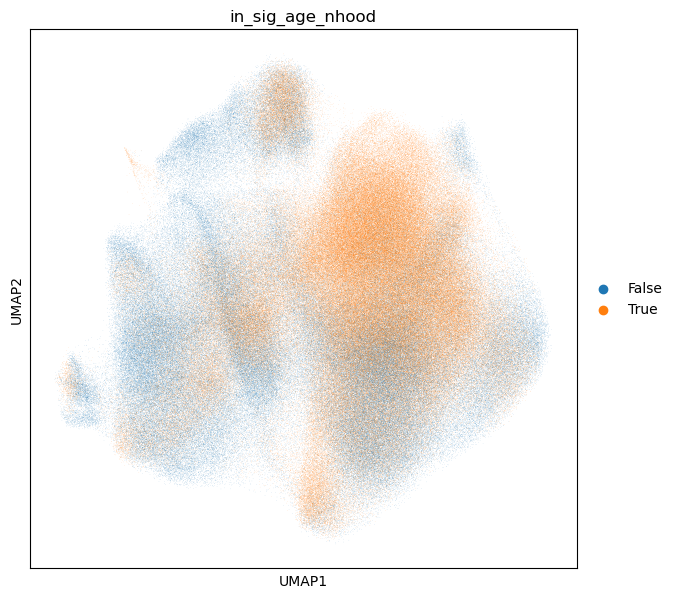

In [39]:
alpha = 0.1

# mark cells that belong to any significant DA neighbourhood
sig_nhoods = (mdata_cd4["milo"].var["SpatialFDR"] < alpha).values
nhoods = mdata_cd4["rna"].obsm["nhoods"]  # cells × nhoods (sparse)

mdata_cd4["rna"].obs["in_sig_age_nhood"] = (
    np.array(nhoods[:, sig_nhoods].sum(axis=1)).ravel() > 0
)

# plot where they sit + show annotation on same embedding
sc.pl.umap(
    mdata_cd4["rna"],
    color=["in_sig_age_nhood", "nhood_annotation", "Age_years", "Sex"],  # change cd4_annot column name
    wspace=0.4
)

In [ ]:
sig_nhoods = mdata_cd4["milo"].var.query(
    "SpatialFDR < 0.1"
).copy()

sig_nhoods.sort_values("logFC", ascending=False).head()

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR,Nhood_size,nhood_annotation,nhood_annotation_frac
71,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.528494,12.054550,8.129364,2.767582e-06,1.176140e-05,1.208698e-05,752.0,Naive/Central memory CD4 T cell,0.929521
1600,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,4.342715,10.169942,8.128945,2.899502e-09,2.212844e-08,2.318103e-08,456.0,CCR4+ CCR6+ memory CD4 T cell,0.831140
3048,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.515392,23.860796,7.850696,6.389141e-12,8.235924e-11,8.694402e-11,1151.0,Naive/Central memory CD4 T cell,0.967854
1377,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,4.155974,11.926955,7.799512,5.411582e-08,3.238135e-07,3.365741e-07,545.0,CCR4+ CCR6+ memory CD4 T cell,0.899083
3081,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.921621,6.780773,7.641122,1.274779e-05,4.699478e-05,4.809262e-05,358.0,Naive/Central memory CD4 T cell,0.910615


<Axes: xlabel='logFC', ylabel='kth_distance'>

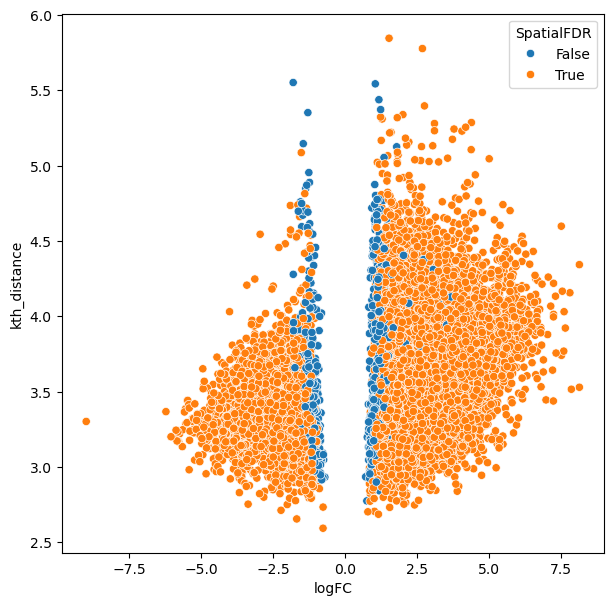

In [ ]:
sns.scatterplot(
    data=sig_nhoods,
    x="logFC",
    y="kth_distance",
    hue=(sig_nhoods["SpatialFDR"] < 0.05)
)

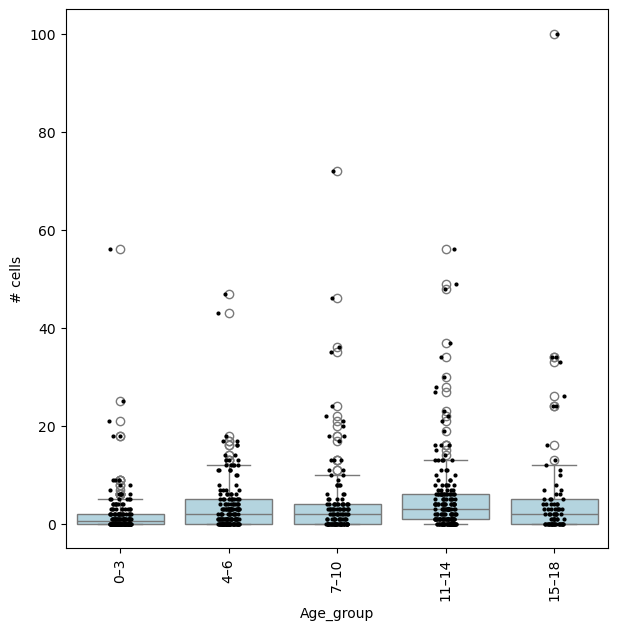

In [ ]:
milo.plot_nhood_counts_by_cond(
    mdata_cd4,
    test_var="Age_years",
    subset_nhoods=sig_nhoods.index[:6],
    log_counts=False
)

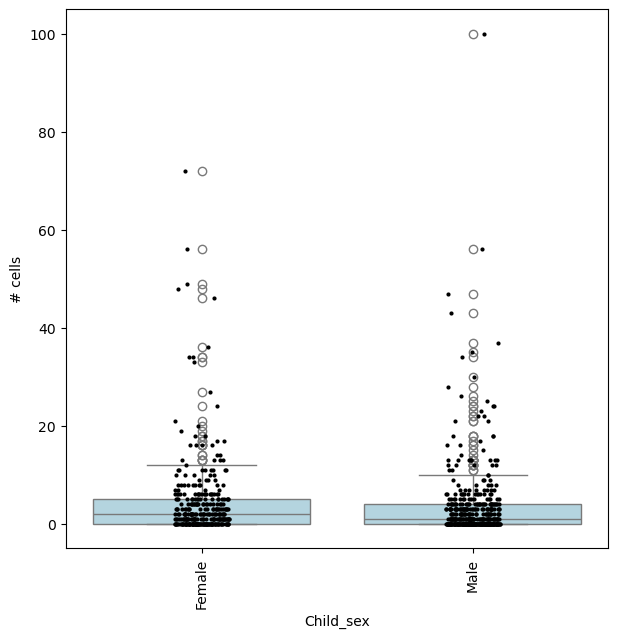

In [ ]:
milo.plot_nhood_counts_by_cond(
    mdata_cd4,
    test_var="Sex",
    subset_nhoods=sig_nhoods.index[:6],
    log_counts=False
)

In [ ]:
pl_nhoods = (
    mdata_cd4["milo"].var.query("SpatialFDR < 0.1")
    .sort_values("logFC", ascending=False)
    .index[:6]
)

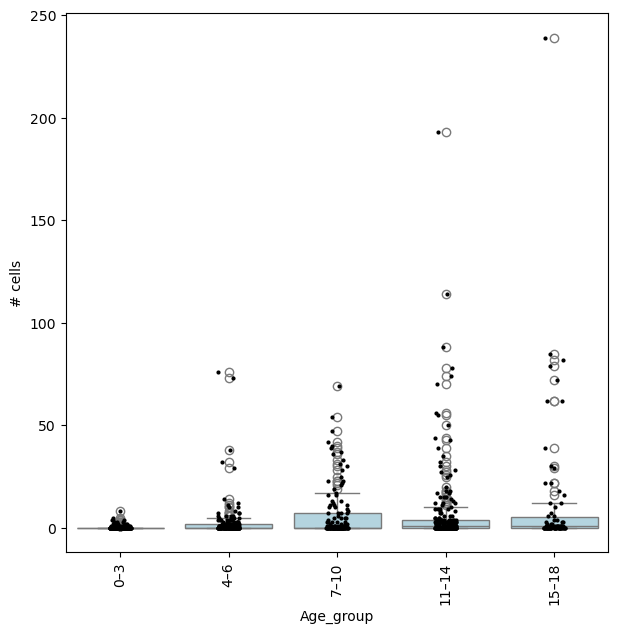

In [ ]:
## Visualize cell counts by condition (x-axis) and individuals on all neighbourhoods
milo.plot_nhood_counts_by_cond(mdata_cd4, test_var="Age_years", subset_nhoods=pl_nhoods, log_counts=False)

In [ ]:
pl_nhoods_neg = (
    mdata_cd4["milo"].var.query("SpatialFDR < 0.1")
    .sort_values("logFC", ascending=True)
    .index[:6]
)

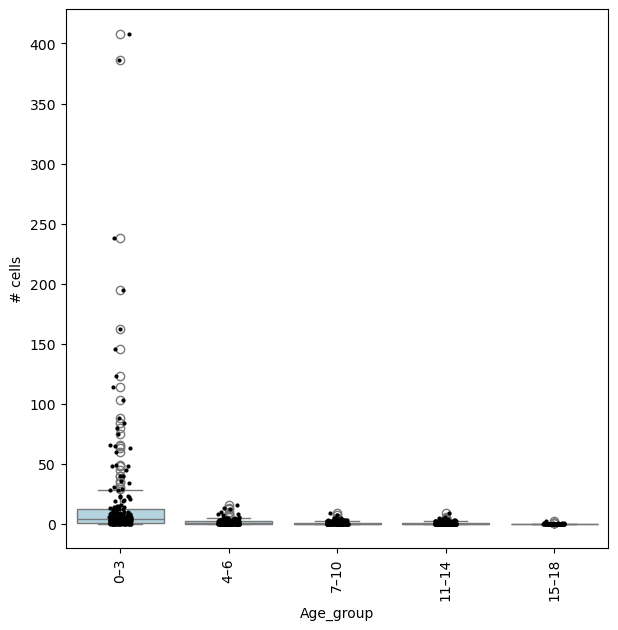

In [ ]:
## Visualize cell counts by condition (x-axis) and individuals on all neighbourhoods
milo.plot_nhood_counts_by_cond(mdata_cd4, test_var="Age_years", subset_nhoods=pl_nhoods_neg, log_counts=False)

In [ ]:
mdata_cd4

MuData object with n_obs × n_vars = 552411 × 24245
  2 modalities
    rna:	552283 x 2889
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age in years int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Child_sex', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Age_group_colors', "Child's sex_colors", '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'pica_broad_cell_type_complete_01_gdT_corrected_colors', 'pica_id_colors', 'sequencing_batch_colors', 'umap', 'pool_id_colors', 'nhood_neighbors_key'
      obsm:	'X_pca', 'X_scVI', 'X_umap